# 1D Linear Advection System — Lax–Friedrichs Scheme

This notebook solves a coupled, linear, hyperbolic system of PDEs with the
**Lax–Friedrichs** finite-difference scheme and validates it against an exact
analytical solution.

The reusable code lives in the `src/` package; this notebook imports it and
focuses on running experiments and presenting results:

- `src/solver.py` — the Lax–Friedrichs solver
- `src/analytical.py` — the exact Riemann-invariant solution
- `src/convergence.py` — the grid-refinement convergence study

**Contents**
1. Problem setup (the physics)
2. The Lax–Friedrichs scheme
3. The exact analytical solution
4. Numerical vs analytical comparison
5. The Courant (CFL) condition
6. Animation of the wave propagation
7. Convergence study


## 1. Problem setup

We solve the coupled system on $x \in [-1, 1]$:

$$
\frac{\partial \rho}{\partial t} + \frac{\partial u}{\partial x} = 0
\qquad\text{(continuity)}
$$
$$
\frac{\partial u}{\partial t} + \frac{\partial \rho}{\partial x} = 0
\qquad\text{(momentum)}
$$

where $\rho$ is a density-like variable and $u$ a velocity-like variable.

**Initial condition — a Riemann problem.** The initial data is a single jump
(discontinuity) at $x = 0$:

$$
(\rho, u) =
\begin{cases}
(0.1,\ 2.0) & x \le 0 \\
(10.0,\ 1.0) & x > 0
\end{cases}
$$

**Boundary conditions.** Neumann (zero-gradient) at both ends: the boundary node
value is copied from its interior neighbour, so $\partial_x \rho = \partial_x u = 0$
at $x = \pm 1$.


## 2. The Lax–Friedrichs scheme

Write the system in conservation form $U_t + F(U)_x = 0$ with
$U = (\rho, u)$ and flux $F(U) = (u, \rho)$. The Lax–Friedrichs update replaces
the value at node $i$ by the **average of its neighbours** and adds a centred
flux difference:

$$
U_i^{\,n+1} = \tfrac{1}{2}\left(U_{i+1}^{\,n} + U_{i-1}^{\,n}\right)
- \frac{\Delta t}{2\,\Delta x}\left(F_{i+1}^{\,n} - F_{i-1}^{\,n}\right).
$$

Component-wise, with coefficient $a = \dfrac{\Delta t}{2\,\Delta x}$:

$$
\rho_i^{\,n+1} = \tfrac{1}{2}\left(\rho_{i+1} + \rho_{i-1}\right) - a\left(u_{i+1} - u_{i-1}\right)
$$
$$
u_i^{\,n+1} = \tfrac{1}{2}\left(u_{i+1} + u_{i-1}\right) - a\left(\rho_{i+1} - \rho_{i-1}\right)
$$

The neighbour-averaging term is what makes the scheme stable (it adds numerical
diffusion); the price is that discontinuities are smeared. Lax–Friedrichs is
**first-order accurate** in space and time.

The time step is set by $\Delta t = C\,\Delta x$ where $C$ is the Courant number
(see Section 5). Since the wave speeds here satisfy $|c| = 1$, we have
$a = C/2$.


In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

# Make the src/ modules importable from the notebooks/ directory.
SRC = os.path.abspath(os.path.join("..", "src"))
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from solver import lax_friedrichs, build_grid      # Lax–Friedrichs scheme
from analytical import analytical_solution         # exact Riemann solution

FIGURES = os.path.abspath(os.path.join("..", "figures"))
os.makedirs(FIGURES, exist_ok=True)

# Grid resolution used for the qualitative plots below.
NX = 1000

## 3. The exact analytical solution

The system decouples under the **Riemann invariants**

$$
w_1 = \rho + u, \qquad w_2 = \rho - u.
$$

Adding and subtracting the two PDEs turns them into two independent linear
advection equations:

$$
\frac{\partial w_1}{\partial t} + \frac{\partial w_1}{\partial x} = 0
\;\Rightarrow\; c = +1,
\qquad
\frac{\partial w_2}{\partial t} - \frac{\partial w_2}{\partial x} = 0
\;\Rightarrow\; c = -1.
$$

Each invariant is transported at constant speed without changing shape:
$w_1(x,t) = w_1^0(x - t)$ and $w_2(x,t) = w_2^0(x + t)$. The initial jump therefore
splits into a right-moving wave (carried by $w_1$) and a left-moving wave
(carried by $w_2$). We recover the primitive variables from

$$
\rho = \tfrac{1}{2}(w_1 + w_2), \qquad u = \tfrac{1}{2}(w_1 - w_2).
$$

This exact solution (implemented in `analytical.py`) is what we validate the
numerical scheme against.


## 4. Numerical vs analytical comparison

Below we overlay the Lax–Friedrichs solution (top row) and the exact solution
(bottom row) at several times. The two waves separate cleanly and travel in
opposite directions. Notice how the numerical scheme captures the wave *speeds*
and *plateau values* correctly but **smears the sharp fronts** — the hallmark of
the first-order numerical diffusion introduced by the neighbour-averaging term.


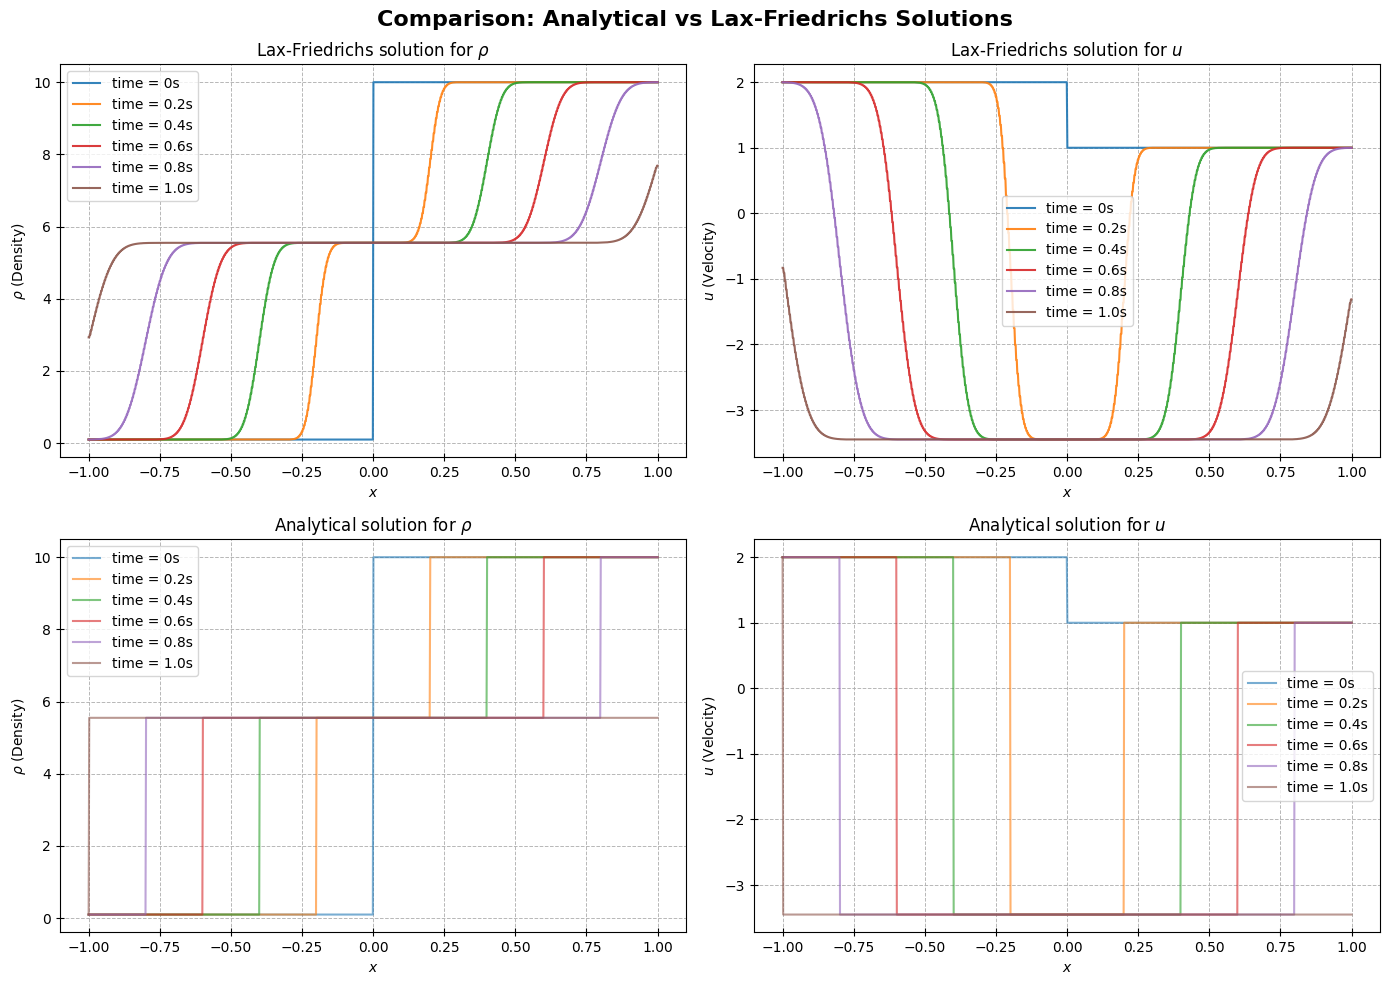

In [2]:
# Compare the Lax–Friedrichs solution against the exact solution at several times.
fig1, ax1 = plt.subplots(2, 2, figsize=(14, 10))
fig1.suptitle("Comparison: Analytical vs Lax-Friedrichs Solutions",
              fontsize=16, fontweight="bold")

time_stamps = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
for t in time_stamps:
    # final column of rho/u corresponds to time t
    x, dx, dt, times, rho, u = lax_friedrichs(t, nx=NX, cfl=0.4)
    rho_anal, u_anal = analytical_solution(x, t)

    ax1[0, 0].plot(x, rho[:, -1], label=f"time = {t}s", lw=1.5, alpha=0.9)
    ax1[0, 1].plot(x, u[:, -1],   label=f"time = {t}s", lw=1.5, alpha=0.9)
    ax1[1, 0].plot(x, rho_anal,   label=f"time = {t}s", lw=1.5, alpha=0.6)
    ax1[1, 1].plot(x, u_anal,     label=f"time = {t}s", lw=1.5, alpha=0.6)

panels = [
    (0, 0, r"Lax-Friedrichs solution for $\rho$", r"$\rho$ (Density)"),
    (0, 1, r"Lax-Friedrichs solution for $u$",    r"$u$ (Velocity)"),
    (1, 0, r"Analytical solution for $\rho$",     r"$\rho$ (Density)"),
    (1, 1, r"Analytical solution for $u$",        r"$u$ (Velocity)"),
]
for r, c, title, ylabel in panels:
    ax1[r, c].set_title(title)
    ax1[r, c].set_xlabel(r"$x$")
    ax1[r, c].set_ylabel(ylabel)
    ax1[r, c].tick_params(axis="both", labelsize=10, direction="inout", length=6)
    ax1[r, c].grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.9)
    ax1[r, c].legend()

fig1.tight_layout()
plt.show()
# A saved copy of this figure is kept in the repository at figures/comparison.png.

## 5. The Courant (CFL) condition

The stability of an explicit scheme for a hyperbolic problem is governed by the
**Courant–Friedrichs–Lewy (CFL) condition**, expressed through the Courant
number

$$
C = \frac{|c|\,\Delta t}{\Delta x}.
$$

Physically, $C$ is the number of grid cells a wave crosses in one time step. For
an explicit scheme the numerical domain of dependence must contain the physical
one, which requires

$$
C \le 1 \quad\text{(stability limit).}
$$

In this code the time step is chosen as $\Delta t = C\,\Delta x$, and since both
wave speeds satisfy $|c| = 1$, the Courant number equals that coefficient
exactly: $C = |c|\,\Delta t/\Delta x = \Delta t/\Delta x$. The scheme coefficient
is then $a = \Delta t/(2\,\Delta x) = C/2$.

The sweep below uses $C = 0.4$, $C = 1.0$ and $C = 1.4$:

- $C = 0.4$ — comfortably stable; smooth, diffused fronts.
- $C = 1.0$ — right at the stability limit; least numerical diffusion (sharpest
  fronts) but no safety margin.
- $C = 1.4 > 1$ — **violates the CFL condition**; the solution develops growing
  oscillations and blows up.


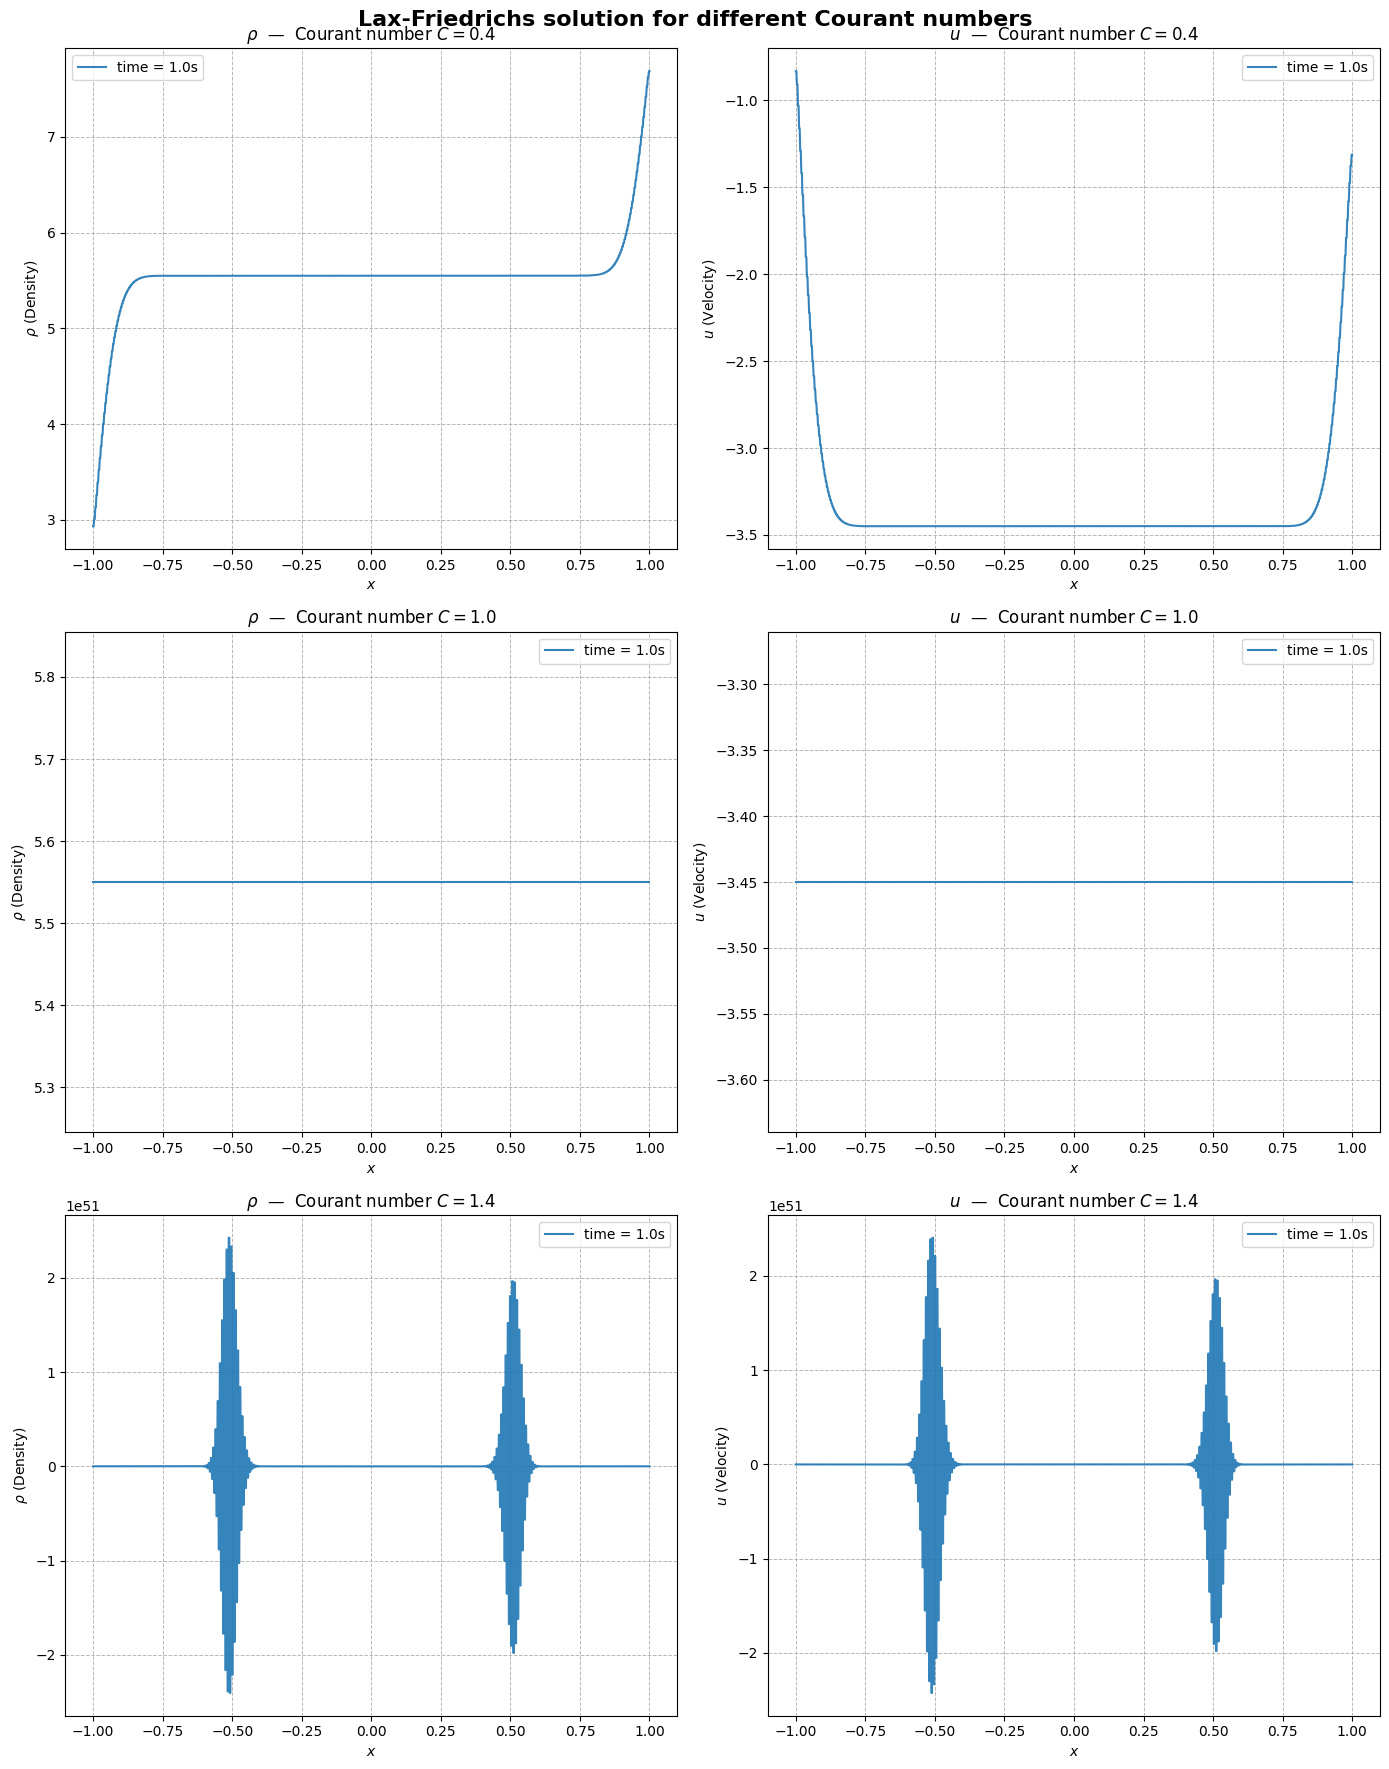

In [3]:
# Sweep the Courant number through stable and unstable regimes.
cfl_values = [0.4, 1.0, 1.4]
fig2, ax2 = plt.subplots(3, 2, figsize=(14, 18))
fig2.suptitle("Lax-Friedrichs solution for different Courant numbers",
              fontsize=16, fontweight="bold")

t = 1.0
for i, C in enumerate(cfl_values):
    x, dx, dt, times, rho, u = lax_friedrichs(t, nx=NX, cfl=C)
    ax2[i, 0].plot(x, rho[:, -1], label=f"time = {t}s", lw=1.5, alpha=0.9)
    ax2[i, 0].set_title(rf"$\rho$  —  Courant number $C = {C}$")
    ax2[i, 0].set_xlabel(r"$x$"); ax2[i, 0].set_ylabel(r"$\rho$ (Density)")
    ax2[i, 0].grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.9)
    ax2[i, 0].legend()

    ax2[i, 1].plot(x, u[:, -1], label=f"time = {t}s", lw=1.5, alpha=0.9)
    ax2[i, 1].set_title(rf"$u$  —  Courant number $C = {C}$")
    ax2[i, 1].set_xlabel(r"$x$"); ax2[i, 1].set_ylabel(r"$u$ (Velocity)")
    ax2[i, 1].grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.9)
    ax2[i, 1].legend()

fig2.tight_layout()
plt.show()
# A saved copy of this figure is kept in the repository at figures/cfl_sweep.png.

## 6. Animation of the wave propagation

The animation shows the right- and left-moving waves separating from the initial
discontinuity over time. It is saved to `figures/`. The cell prefers `ffmpeg`
(producing an `.mp4`) and falls back to Pillow (producing a `.gif`) when
`ffmpeg` is not installed, so it runs in either environment.


In [4]:
# Animate the wave propagation. Uses ffmpeg (mp4) when available and otherwise
# falls back to Pillow (gif), so the notebook runs even without ffmpeg.
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from matplotlib.animation import writers as mpl_writers

t_final = 1.0
C = 0.4
x, dx, dt, times, rho, u = lax_friedrichs(t_final, nx=NX, cfl=C)
nt = rho.shape[1] - 1

def padded(lo, hi, frac=0.05):
    pad = frac * (hi - lo)
    return lo - pad, hi + pad

rho_lim = padded(rho.min(), rho.max())
u_lim = padded(u.min(), u.max())

fig, (axr, axu) = plt.subplots(2, 1, figsize=(10, 8))
fig.suptitle("Wave Propagation using Lax-Friedrichs Scheme",
             fontsize=16, fontweight="bold")

line1, = axr.plot([], [], lw=2, color="tab:blue", label=r"Density $\rho$")
line2, = axu.plot([], [], lw=2, color="tab:orange", label=r"Velocity $u$")
axr.set_xlim(x[0], x[-1]); axr.set_ylim(*rho_lim)
axr.set_xlabel("x"); axr.set_ylabel(r"Density $\rho$"); axr.grid(True); axr.legend()
axu.set_xlim(x[0], x[-1]); axu.set_ylim(*u_lim)
axu.set_xlabel("x"); axu.set_ylabel(r"Velocity $u$"); axu.grid(True); axu.legend()
time_text = axu.text(0.02, 0.9, "", transform=axu.transAxes, fontsize=12, color="blue")

def init():
    line1.set_data([], []); line2.set_data([], []); time_text.set_text("")
    return line1, line2, time_text

def update(frame):
    line1.set_data(x, rho[:, frame])
    line2.set_data(x, u[:, frame])
    time_text.set_text(f"Time = {frame * dt:.3f} s")
    return line1, line2, time_text

ani = FuncAnimation(fig, update, frames=range(0, nt, 5),
                    init_func=init, blit=True, interval=40)

if mpl_writers.is_available("ffmpeg"):
    out = os.path.join(FIGURES, "lax_friedrichs_wave.mp4")
    ani.save(out, writer=FFMpegWriter(fps=30, bitrate=1800))
else:
    out = os.path.join(FIGURES, "lax_friedrichs_wave.gif")
    ani.save(out, writer=PillowWriter(fps=30))
plt.close(fig)
print(f"Animation saved to: {out}")

Animation saved to: /Users/bhavik/Desktop/comp_phy_project/lax_friedrichs_advection/figures/lax_friedrichs_wave.gif


## 7. Convergence study

A qualitative "looks right" comparison is not enough — we want to **quantify**
how fast the numerical error shrinks as the grid is refined.

**Method.** We run the solver at increasing resolutions
$n_x = 100, 200, 400, 800, 1600$, each to the **same** fixed final time
($t = 0.4$, chosen so both waves stay inside the domain) and with the **same**
fixed Courant number ($C = 0.8$). At each resolution we measure the error against
the exact solution in grid-normalised discrete norms so the values are
comparable across resolutions:

$$
\|e\|_1 = \Delta x \sum_i |e_i|,
\qquad
\|e\|_2 = \sqrt{\Delta x \sum_i e_i^2}.
$$

The exact solution is evaluated at the *actual* reached time
$n_t\,\Delta t$ (not the nominal $t_\text{final}$), so the rounding in
$n_t = \lfloor t_\text{final}/\Delta t\rfloor$ does not contaminate the error.

The **order of accuracy** $p$ is the slope of a log–log fit of error against
$\Delta x$ (error $\sim \Delta x^{\,p}$).


In [5]:
from convergence import run_convergence, estimate_order, plot_convergence

nx_list = [100, 200, 400, 800, 1600]
t_conv = 0.4     # both waves (|c| = 1) travel 0.4 and stay inside [-1, 1]
cfl_conv = 0.8   # fixed Courant number, safely below the C = 1 stability limit

nx, dx, rho_l1, rho_l2, u_l1, u_l2 = run_convergence(nx_list, t_final=t_conv, cfl=cfl_conv)

print(f"{'nx':>6}{'dx':>11}{'rho L1':>13}{'rho L2':>13}{'u L1':>13}{'u L2':>13}")
for i in range(len(nx)):
    print(f"{nx[i]:>6}{dx[i]:>11.5f}{rho_l1[i]:>13.4e}"
          f"{rho_l2[i]:>13.4e}{u_l1[i]:>13.4e}{u_l2[i]:>13.4e}")

print("\nFitted order of accuracy (log-log slope):")
print(f"  rho:  L1 = {estimate_order(dx, rho_l1):.3f}   "
      f"L2 = {estimate_order(dx, rho_l2):.3f}")
print(f"  u:    L1 = {estimate_order(dx, u_l1):.3f}   "
      f"L2 = {estimate_order(dx, u_l2):.3f}")

    nx         dx       rho L1       rho L2         u L1         u L2
   100    0.01980   4.7955e-01   8.8201e-01   4.7955e-01   8.8201e-01
   200    0.00995   3.2790e-01   6.8864e-01   3.2790e-01   6.8864e-01
   400    0.00499   2.3440e-01   5.8403e-01   2.3440e-01   5.8403e-01
   800    0.00250   1.6665e-01   4.9324e-01   1.6665e-01   4.9324e-01
  1600    0.00125   1.1816e-01   4.1567e-01   1.1816e-01   4.1567e-01

Fitted order of accuracy (log-log slope):
  rho:  L1 = 0.503   L2 = 0.266
  u:    L1 = 0.503   L2 = 0.266


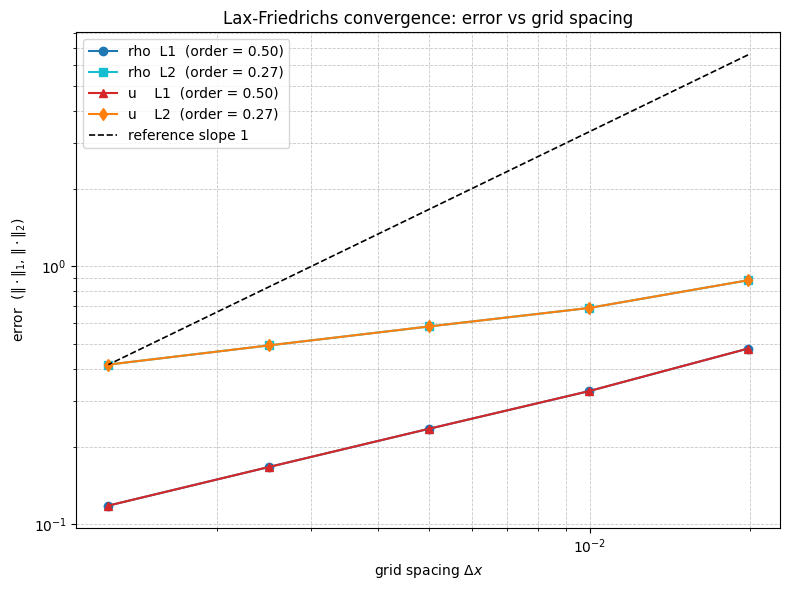

In [6]:
plot_convergence(dx, rho_l1, rho_l2, u_l1, u_l2)

### Interpreting the results

The error does decrease monotonically under refinement, and the log–log data lie
on a straight line — the scheme **converges**. But the fitted slopes sit **below
1**: roughly $p \approx 0.5$ in the $L_1$ norm and $p \approx 0.25$–$0.5$ in the
$L_2$ norm, clearly shallower than the slope-1 reference line.

This is expected and honest. Lax–Friedrichs is formally *first-order* for
**smooth** solutions, so a slope near 1 is the textbook expectation. Our solution
is a **Riemann problem containing discontinuities**, and convergence is degraded
at a discontinuity: the numerical diffusion smears each shock over a fixed number
of cells, i.e. a physical width $\sim \Delta x$, and integrating that error gives
a classic $L_1$ rate of about $1/2$ for a monotone first-order scheme (with the
$L_2$ rate lower still, and $L_\infty$ not converging at all).

**Takeaways:**

- The scheme is verified: error $\to 0$ as $\Delta x \to 0$, at a clean, stable rate.
- The *observed* order (~0.5 in $L_1$) is below the *formal* order (1) because the
  solution is discontinuous — the loss of accuracy is concentrated at the shocks,
  not in the smooth regions.
- Recovering the full first-order rate would require a smooth solution; capturing
  sharp discontinuities more accurately would require a higher-resolution
  (e.g. slope-limited / Godunov-type) scheme.
